<a href="https://colab.research.google.com/github/vashirij/wildfire-tinyml-self-sufficiency/blob/main/Notebooks/05_Energy_Harvesting_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 Energy-Harvesting and Energy-Aware Operation

## Objectives

- Load the realistic environmental stream.
- Model harvested solar energy and battery state.
- Estimate sensing, inference, communication, and idle energy.
- Implement energy-aware operating modes.
- Compare fixed-rate and adaptive sensing policies.
- Measure energy use, alert performance, duty cycle, and battery sustainability.
- Save results, figures, and configuration artifacts.

> Energy values in this notebook are simulation estimates. They are not physical hardware measurements.


In [ ]:
from pathlib import Path
from dataclasses import dataclass
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Mount Google Drive and define paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/WildfireProject")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "simulated"
    / "realistic"
    / "realistic_environment_stream.csv"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "pseudo_labeling"
    / "pseudo_label_model.joblib"
)

RESULTS_DIR = PROJECT_ROOT / "results" / "energy"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
PREDICTIONS_DIR = PROJECT_ROOT / "results" / "predictions"
FIGURES_DIR = PROJECT_ROOT / "figures" / "energy"
CONFIG_DIR = PROJECT_ROOT / "docs" / "config"

for folder in [
    RESULTS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    CONFIG_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", DATA_PATH.exists())
print("Model exists:", MODEL_PATH.exists())


Mounted at /content/drive
Dataset exists: True
Model exists: True


## 2. Load dataset and trained detector

In [ ]:
import joblib

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Run 01B_Realistic_Environmental_Simulator.ipynb first."
    )

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found at {MODEL_PATH}. "
        "Run 04_Label_Free_Pseudo_Labeling.ipynb first."
    )

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
model = joblib.load(MODEL_PATH)

FEATURE_COLUMNS = [
    "temperature_c",
    "humidity_percent",
    "smoke_ppm",
    "co_ppm",
    "wind_speed_kmh"
]

TARGET_COLUMN = "wildfire"

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (20000, 15)


,timestamp,temperature_c,humidity_percent,smoke_ppm,co_ppm,wind_speed_kmh,solar_power_w,battery_voltage,wildfire,environment_state,fire_phase,fire_severity,fire_event_id,missing_packet,sample_index
0,2026-07-27 00:00:00,13.347181,76.569494,14.397654,0.730587,8.031726,0.0,4.14997,0,sensor_spike,none,0.0,0,False,0
1,2026-07-27 00:00:01,14.356494,64.187253,0.246029,0.580671,6.474338,0.0,4.14994,0,normal,none,0.0,0,False,1
2,2026-07-27 00:00:02,13.320607,85.195248,1.656730,0.937621,7.469129,0.0,4.14991,0,normal,none,0.0,0,False,2
3,2026-07-27 00:00:03,14.112753,68.244563,2.435927,0.366247,8.917727,0.0,4.14988,0,normal,none,0.0,0,False,3
4,2026-07-27 00:00:04,14.849696,67.837010,0.279561,1.479401,7.423717,0.0,4.14985,0,normal,none,0.0,0,False,4


## 3. Energy model configuration

In [ ]:
@dataclass
class EnergyConfig:
    battery_capacity_mah: float = 2000.0
    nominal_voltage_v: float = 3.7

    initial_state_of_charge: float = 0.75
    minimum_state_of_charge: float = 0.10
    maximum_state_of_charge: float = 1.00

    sensing_energy_mj: float = 0.20
    inference_energy_mj: float = 0.08
    transmission_energy_mj: float = 2.50
    idle_energy_mj_per_second: float = 0.015
    deep_sleep_energy_mj_per_second: float = 0.0015

    solar_conversion_efficiency: float = 0.72
    fire_decision_threshold: float = 0.30

    high_energy_threshold: float = 0.65
    medium_energy_threshold: float = 0.40
    low_energy_threshold: float = 0.20

config = EnergyConfig()

BATTERY_CAPACITY_MJ = (
    config.battery_capacity_mah
    * config.nominal_voltage_v
    * 3.6
)

print("Battery capacity:", round(BATTERY_CAPACITY_MJ, 2), "mJ")


Battery capacity: 26640.0 mJ


## 4. Define energy-aware operating modes

In [ ]:
OPERATING_MODES = {
    "high": {
        "sample_interval": 1,
        "run_inference": True,
        "transmit_all_alerts": True
    },
    "medium": {
        "sample_interval": 5,
        "run_inference": True,
        "transmit_all_alerts": True
    },
    "low": {
        "sample_interval": 15,
        "run_inference": True,
        "transmit_all_alerts": False
    },
    "critical": {
        "sample_interval": 60,
        "run_inference": False,
        "transmit_all_alerts": False
    }
}


def choose_operating_mode(state_of_charge):
    if state_of_charge >= config.high_energy_threshold:
        return "high"

    if state_of_charge >= config.medium_energy_threshold:
        return "medium"

    if state_of_charge >= config.low_energy_threshold:
        return "low"

    return "critical"


## 5. Energy conversion helpers

In [ ]:
def harvested_energy_mj(solar_power_w, interval_seconds):
    return (
        max(0.0, solar_power_w)
        * interval_seconds
        * 1000
        * config.solar_conversion_efficiency
    )


def state_of_charge_from_energy(energy_mj):
    return float(
        np.clip(
            energy_mj / BATTERY_CAPACITY_MJ,
            config.minimum_state_of_charge,
            config.maximum_state_of_charge
        )
    )


def predict_fire_probability(row):
    sample = pd.DataFrame(
        [row[FEATURE_COLUMNS].to_dict()],
        columns=FEATURE_COLUMNS
    )

    return float(model.predict_proba(sample)[0, 1])


## 6. Fixed-rate baseline policy

In [ ]:
def run_fixed_rate_policy(dataframe):
    battery_energy = (
        BATTERY_CAPACITY_MJ
        * config.initial_state_of_charge
    )

    records = []

    for position, (_, row) in enumerate(dataframe.iterrows()):
        interval = 1

        harvested = harvested_energy_mj(
            row["solar_power_w"],
            interval
        )

        probability = predict_fire_probability(row)
        prediction = int(
            probability >= config.fire_decision_threshold
        )

        sensing_energy = config.sensing_energy_mj
        inference_energy = config.inference_energy_mj
        transmission_energy = (
            config.transmission_energy_mj
            if prediction == 1
            else 0.0
        )
        idle_energy = config.idle_energy_mj_per_second

        consumed = (
            sensing_energy
            + inference_energy
            + transmission_energy
            + idle_energy
        )

        battery_energy = np.clip(
            battery_energy + harvested - consumed,
            BATTERY_CAPACITY_MJ * config.minimum_state_of_charge,
            BATTERY_CAPACITY_MJ
        )

        records.append({
            "timestamp": row["timestamp"],
            "sample_index": int(row["sample_index"]),
            "true_label": int(row[TARGET_COLUMN]),
            "fire_probability": probability,
            "prediction": prediction,
            "mode": "fixed",
            "sampled": True,
            "transmitted": prediction == 1,
            "harvested_energy_mj": harvested,
            "consumed_energy_mj": consumed,
            "battery_energy_mj": battery_energy,
            "state_of_charge": state_of_charge_from_energy(
                battery_energy
            )
        })

    return pd.DataFrame(records)


## 7. Adaptive energy-aware policy

In [ ]:
def run_adaptive_policy(dataframe):
    battery_energy = (
        BATTERY_CAPACITY_MJ
        * config.initial_state_of_charge
    )

    records = []
    last_prediction = 0

    for position, (_, row) in enumerate(dataframe.iterrows()):
        state_of_charge = state_of_charge_from_energy(
            battery_energy
        )

        mode = choose_operating_mode(state_of_charge)
        settings = OPERATING_MODES[mode]
        interval = settings["sample_interval"]

        sampled = position % interval == 0
        prediction = last_prediction
        probability = np.nan
        transmitted = False

        sensing_energy = 0.0
        inference_energy = 0.0
        transmission_energy = 0.0

        if sampled:
            sensing_energy = config.sensing_energy_mj

            if settings["run_inference"]:
                probability = predict_fire_probability(row)
                prediction = int(
                    probability
                    >= config.fire_decision_threshold
                )
                last_prediction = prediction
                inference_energy = (
                    config.inference_energy_mj
                )

                should_transmit = (
                    prediction == 1
                    and (
                        settings["transmit_all_alerts"]
                        or probability >= 0.80
                    )
                )

                if should_transmit:
                    transmitted = True
                    transmission_energy = (
                        config.transmission_energy_mj
                    )

        harvested = harvested_energy_mj(
            row["solar_power_w"],
            1
        )

        if mode == "critical":
            idle_energy = (
                config.deep_sleep_energy_mj_per_second
            )
        else:
            idle_energy = (
                config.idle_energy_mj_per_second
            )

        consumed = (
            sensing_energy
            + inference_energy
            + transmission_energy
            + idle_energy
        )

        battery_energy = np.clip(
            battery_energy + harvested - consumed,
            BATTERY_CAPACITY_MJ
            * config.minimum_state_of_charge,
            BATTERY_CAPACITY_MJ
        )

        records.append({
            "timestamp": row["timestamp"],
            "sample_index": int(row["sample_index"]),
            "true_label": int(row[TARGET_COLUMN]),
            "fire_probability": probability,
            "prediction": prediction,
            "mode": mode,
            "sampled": sampled,
            "transmitted": transmitted,
            "harvested_energy_mj": harvested,
            "consumed_energy_mj": consumed,
            "battery_energy_mj": battery_energy,
            "state_of_charge": state_of_charge_from_energy(
                battery_energy
            )
        })

    return pd.DataFrame(records)


## 8. Run both policies

In [ ]:
fixed_results = run_fixed_rate_policy(df)
adaptive_results = run_adaptive_policy(df)

print("Fixed-rate rows:", len(fixed_results))
print("Adaptive rows:", len(adaptive_results))


## 9. Evaluation helpers

In [10]:
def false_alarm_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return fp / (fp + tn) if (fp + tn) > 0 else 0.0


def summarize_policy(name, results):
    y_true = results["true_label"]
    y_pred = results["prediction"]

    total_consumed = results[
        "consumed_energy_mj"
    ].sum()

    total_harvested = results[
        "harvested_energy_mj"
    ].sum()

    return {
        "policy": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1_score": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "false_alarm_rate": false_alarm_rate(
            y_true, y_pred
        ),
        "total_energy_consumed_mj": total_consumed,
        "total_energy_harvested_mj": total_harvested,
        "net_energy_mj": total_harvested - total_consumed,
        "final_state_of_charge": results[
            "state_of_charge"
        ].iloc[-1],
        "samples_processed": int(
            results["sampled"].sum()
        ),
        "alerts_transmitted": int(
            results["transmitted"].sum()
        )
    }


## 10. Compare policies

In [11]:
comparison_df = pd.DataFrame([
    summarize_policy(
        "Fixed-Rate Policy",
        fixed_results
    ),
    summarize_policy(
        "Adaptive Energy-Aware Policy",
        adaptive_results
    )
])

fixed_energy = comparison_df.loc[
    comparison_df["policy"] == "Fixed-Rate Policy",
    "total_energy_consumed_mj"
].iloc[0]

comparison_df["energy_savings_vs_fixed"] = (
    1
    - comparison_df["total_energy_consumed_mj"]
    / fixed_energy
)

display(comparison_df.round(4))


,policy,accuracy,precision,recall,f1_score,false_alarm_rate,total_energy_consumed_mj,total_energy_harvested_mj,net_energy_mj,final_state_of_charge,samples_processed,alerts_transmitted,energy_savings_vs_fixed
0,Fixed-Rate Policy,0.9232,0.9427,0.7877,0.8583,0.0201,18242.5,0.0,-18242.5,0.100,20000,4937,0.0000
1,Adaptive Energy-Aware Policy,0.9197,0.9340,0.7835,0.8522,0.0232,5995.2,0.0,-5995.2,0.525,6340,1568,0.6714


## 11. Operating-mode distribution

In [12]:
mode_distribution = (
    adaptive_results["mode"]
    .value_counts()
    .rename_axis("mode")
    .reset_index(name="samples")
)

mode_distribution["fraction"] = (
    mode_distribution["samples"]
    / len(adaptive_results)
)

display(mode_distribution)


,mode,samples,fraction
0,medium,17075,0.85375
1,high,2925,0.14625


## 12. Event-level detection delay

In [13]:
def calculate_event_delays(
    source_df,
    results_df,
    sampling_interval_seconds=1
):
    combined = pd.DataFrame({
        "fire_event_id": source_df["fire_event_id"].to_numpy(),
        "true_label": source_df[TARGET_COLUMN].to_numpy(),
        "prediction": results_df["prediction"].to_numpy()
    })

    event_ids = sorted(
        event_id
        for event_id in combined["fire_event_id"].unique()
        if event_id > 0
    )

    rows = []

    for event_id in event_ids:
        event_rows = combined[
            combined["fire_event_id"] == event_id
        ]

        positions = np.where(
            event_rows["prediction"].to_numpy() == 1
        )[0]

        detected = len(positions) > 0

        delay = (
            int(positions[0])
            * sampling_interval_seconds
            if detected
            else np.nan
        )

        rows.append({
            "fire_event_id": int(event_id),
            "detected": detected,
            "detection_delay_seconds": delay
        })

    return pd.DataFrame(rows)


fixed_delay_df = calculate_event_delays(
    df,
    fixed_results
)

adaptive_delay_df = calculate_event_delays(
    df,
    adaptive_results
)

fixed_delay_df["policy"] = "Fixed-Rate Policy"
adaptive_delay_df["policy"] = (
    "Adaptive Energy-Aware Policy"
)

delay_df = pd.concat(
    [fixed_delay_df, adaptive_delay_df],
    ignore_index=True
)

delay_summary_df = (
    delay_df
    .groupby("policy")
    .agg(
        total_events=("fire_event_id", "count"),
        detected_events=("detected", "sum"),
        average_delay_seconds=(
            "detection_delay_seconds", "mean"
        ),
        maximum_delay_seconds=(
            "detection_delay_seconds", "max"
        )
    )
    .reset_index()
)

delay_summary_df["event_detection_rate"] = (
    delay_summary_df["detected_events"]
    / delay_summary_df["total_events"]
)

display(delay_summary_df.round(4))


,policy,total_events,detected_events,average_delay_seconds,maximum_delay_seconds,event_detection_rate
0,Adaptive Energy-Aware Policy,20,20,29.85,66,1.0
1,Fixed-Rate Policy,20,20,15.05,59,1.0


## 13. Save metrics and detailed results

In [14]:
comparison_path = (
    METRICS_DIR
    / "week5_energy_policy_comparison.csv"
)

mode_path = (
    RESULTS_DIR
    / "week5_operating_mode_distribution.csv"
)

delay_path = (
    RESULTS_DIR
    / "week5_detection_delay.csv"
)

delay_summary_path = (
    METRICS_DIR
    / "week5_detection_delay_summary.csv"
)

fixed_path = (
    PREDICTIONS_DIR
    / "week5_fixed_rate_energy_results.csv"
)

adaptive_path = (
    PREDICTIONS_DIR
    / "week5_adaptive_energy_results.csv"
)

comparison_df.to_csv(comparison_path, index=False)
mode_distribution.to_csv(mode_path, index=False)
delay_df.to_csv(delay_path, index=False)
delay_summary_df.to_csv(
    delay_summary_path,
    index=False
)
fixed_results.to_csv(fixed_path, index=False)
adaptive_results.to_csv(adaptive_path, index=False)

print("Results saved successfully.")


Results saved successfully.


## 14. Plot battery state of charge

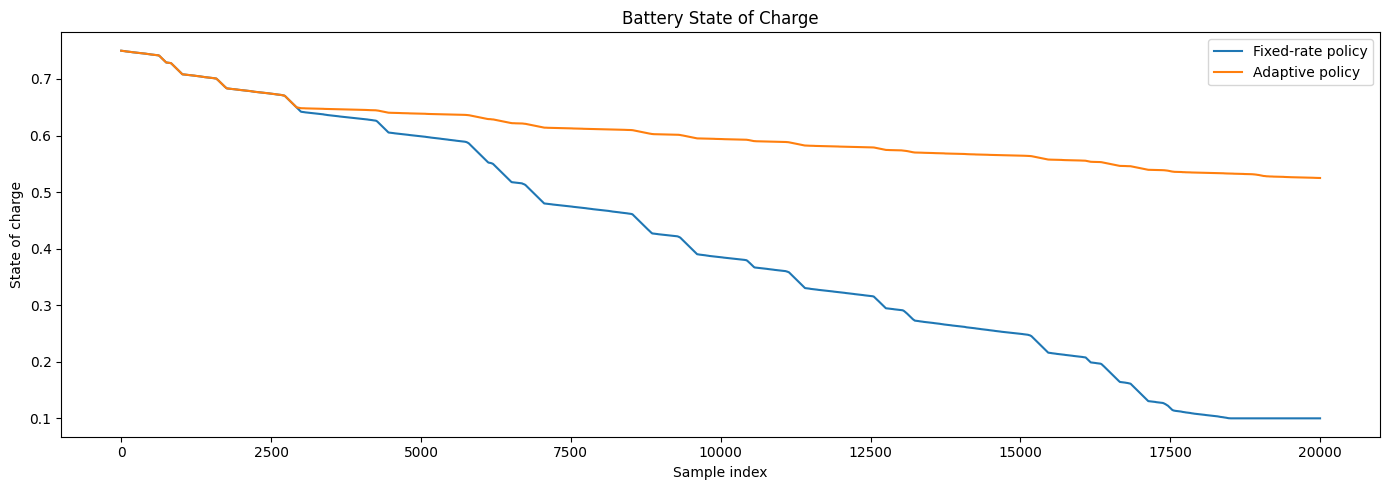

In [15]:
plt.figure(figsize=(14, 5))

plt.plot(
    fixed_results["sample_index"],
    fixed_results["state_of_charge"],
    label="Fixed-rate policy"
)

plt.plot(
    adaptive_results["sample_index"],
    adaptive_results["state_of_charge"],
    label="Adaptive policy"
)

plt.xlabel("Sample index")
plt.ylabel("State of charge")
plt.title("Battery State of Charge")
plt.legend()
plt.tight_layout()

battery_path = (
    FIGURES_DIR
    / "battery_state_of_charge.png"
)

plt.savefig(
    battery_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 15. Plot cumulative energy use

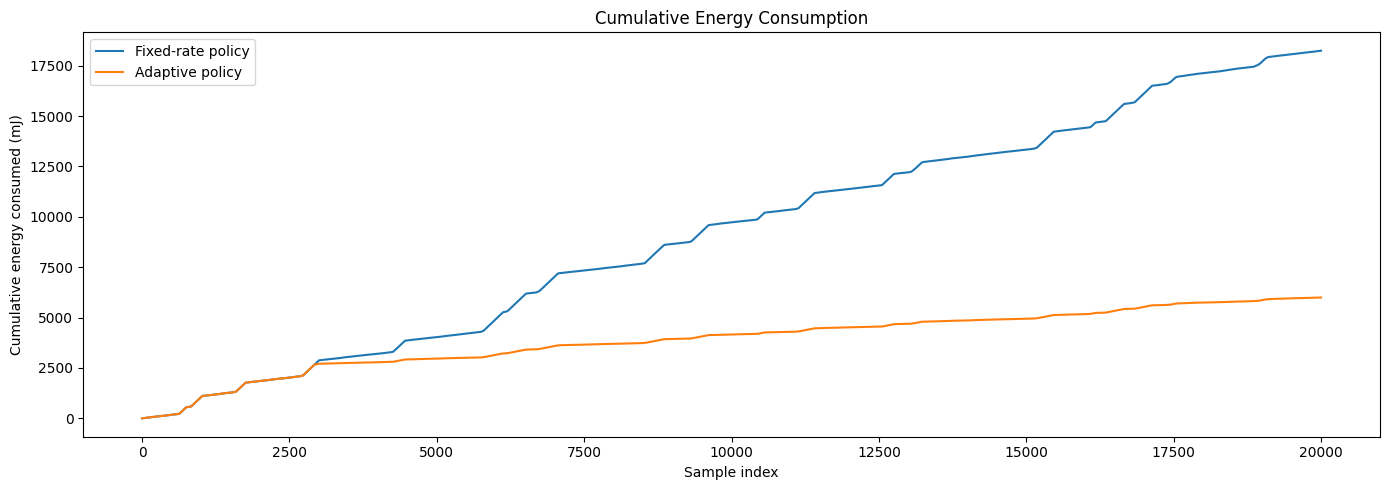

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    fixed_results["sample_index"],
    fixed_results["consumed_energy_mj"].cumsum(),
    label="Fixed-rate policy"
)

plt.plot(
    adaptive_results["sample_index"],
    adaptive_results["consumed_energy_mj"].cumsum(),
    label="Adaptive policy"
)

plt.xlabel("Sample index")
plt.ylabel("Cumulative energy consumed (mJ)")
plt.title("Cumulative Energy Consumption")
plt.legend()
plt.tight_layout()

energy_path = (
    FIGURES_DIR
    / "cumulative_energy_consumption.png"
)

plt.savefig(
    energy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 16. Plot operating modes

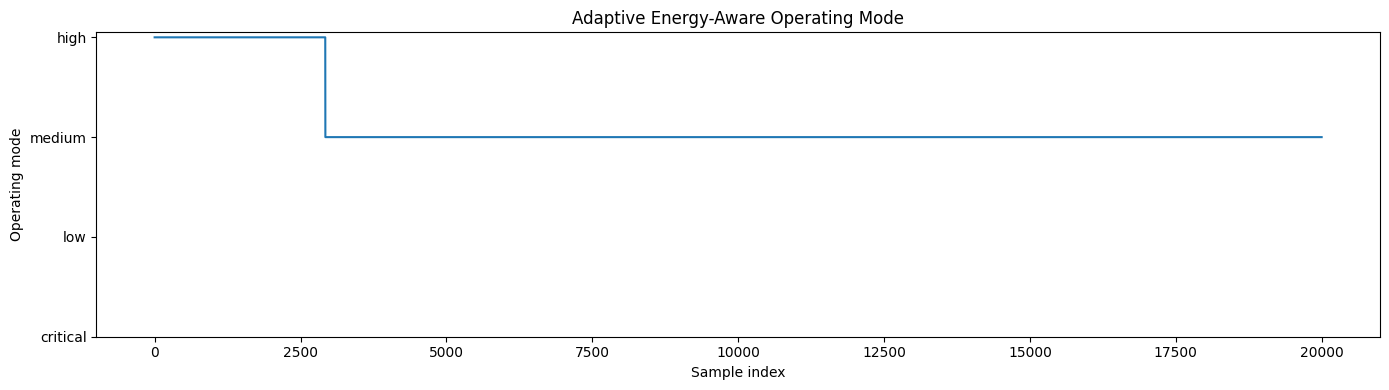

In [17]:
mode_mapping = {
    "critical": 0,
    "low": 1,
    "medium": 2,
    "high": 3
}

mode_values = adaptive_results["mode"].map(
    mode_mapping
)

plt.figure(figsize=(14, 4))

plt.plot(
    adaptive_results["sample_index"],
    mode_values
)

plt.yticks(
    [0, 1, 2, 3],
    ["critical", "low", "medium", "high"]
)

plt.xlabel("Sample index")
plt.ylabel("Operating mode")
plt.title("Adaptive Energy-Aware Operating Mode")
plt.tight_layout()

mode_figure_path = (
    FIGURES_DIR
    / "adaptive_operating_modes.png"
)

plt.savefig(
    mode_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 17. Final summary

In [18]:
adaptive_row = comparison_df[
    comparison_df["policy"]
    == "Adaptive Energy-Aware Policy"
].iloc[0]

summary_df = pd.DataFrame([{
    "policy": "Adaptive Energy-Aware Policy",
    "accuracy": adaptive_row["accuracy"],
    "precision": adaptive_row["precision"],
    "recall": adaptive_row["recall"],
    "f1_score": adaptive_row["f1_score"],
    "false_alarm_rate": adaptive_row[
        "false_alarm_rate"
    ],
    "energy_consumed_mj": adaptive_row[
        "total_energy_consumed_mj"
    ],
    "energy_harvested_mj": adaptive_row[
        "total_energy_harvested_mj"
    ],
    "energy_savings_vs_fixed": adaptive_row[
        "energy_savings_vs_fixed"
    ],
    "final_state_of_charge": adaptive_row[
        "final_state_of_charge"
    ],
    "samples_processed": adaptive_row[
        "samples_processed"
    ],
    "alerts_transmitted": adaptive_row[
        "alerts_transmitted"
    ]
}])

summary_path = (
    RESULTS_DIR
    / "week5_energy_summary.csv"
)

summary_df.to_csv(summary_path, index=False)

display(summary_df.round(4))

print("=" * 70)
print("ENERGY-AWARE SIMULATION COMPLETED SUCCESSFULLY")
print("=" * 70)
print(
    "Energy savings:",
    f"{adaptive_row['energy_savings_vs_fixed']:.2%}"
)
print(
    "Final state of charge:",
    f"{adaptive_row['final_state_of_charge']:.2%}"
)
print(
    "Recall:",
    round(adaptive_row["recall"], 4)
)
print(
    "F1-score:",
    round(adaptive_row["f1_score"], 4)
)


,policy,accuracy,precision,recall,f1_score,false_alarm_rate,energy_consumed_mj,energy_harvested_mj,energy_savings_vs_fixed,final_state_of_charge,samples_processed,alerts_transmitted
0,Adaptive Energy-Aware Policy,0.9197,0.934,0.7835,0.8522,0.0232,5995.2,0.0,0.6714,0.525,6340,1568


ENERGY-AWARE SIMULATION COMPLETED SUCCESSFULLY
Energy savings: 67.14%
Final state of charge: 52.50%
Recall: 0.7835
F1-score: 0.8522
